# Interactive simulation of test case study

First load packages and switch into the correct working directory

In [1]:
from pymob import Config

from lotka_volterra_case_study.sim import Simulation_v2

ModuleNotFoundError: No module named 'lotka_volterra_case_study'

Load casestudy

In [2]:
config = Config("../scenarios/test_scenario_v2/settings.cfg")
config.case_study.package = "../.."

sim = Simulation_v2(config)
sim.setup()


MinMaxScaler(variable=rabbits, min=5.968110437683305, max=86.99133665713266)
MinMaxScaler(variable=wolves, min=7.203778019337644, max=62.829641338400535)
Results directory exists at 'c:\Users\Markus\pymob\lotka_volterra_case_study\results\test_scenario_v2'.
Scenario directory exists at 'c:\Users\Markus\pymob\lotka_volterra_case_study\scenarios\test_scenario_v2'.


c:\Users\Markus\anaconda3\envs\lotka_volterra\Lib\site-packages\pymob\simulation.py:546: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_ode_states = <n>'. Extracted the return arguments ['dprey_dt', 'dpredator_dt'] from the source code. Setting 'n_ode_states=2.
  warnings.warn(


In [3]:
# Prey birth rate (alpha * prey)
sim.config.model_parameters.alpha.min = 0.1
sim.config.model_parameters.alpha.max = 1.0
sim.config.model_parameters.alpha.free = True

# Predation rate (- beta * prey * predator)
sim.config.model_parameters.beta.min = 0.005
sim.config.model_parameters.beta.max = 0.05
sim.config.model_parameters.beta.free = True

# Predator reproduction rate (delta * prey * predator)
sim.config.model_parameters.delta.min = 0.005
sim.config.model_parameters.delta.max = 0.05
sim.config.model_parameters.delta.free = False

# Predator death rate (- gamma * predator)
sim.config.model_parameters.gamma.min = 0.1
sim.config.model_parameters.gamma.max = 1.0
sim.config.model_parameters.gamma.free = False


## Run interactive simulation

In [4]:
sim.interactive()

In [14]:
sim.config.model_parameters.gamma.prior = "lognorm(loc = 0.3, scale = 0.5)"
sim.config.model_parameters.delta.prior = "lognorm(loc = 0.1, scale = 0.25)"

In [15]:
sim.config.jaxsolver.throw_exception = False
sim.dispatch_constructor()

sim.set_inferer("numpyro")
sim.inferer.config.inference_numpyro.kernel = "nuts"

sim.inferer.run()

sim.inferer.idata.posterior

Jax 64 bit mode: False
Absolute tolerance: 1e-07


c:\Users\Markus\anaconda3\envs\lotka_volterra\Lib\site-packages\pymob\inference\numpyro_backend.py:552: UserWarning: Model is not rendered, because the graphviz executable is not found. Try search for 'graphviz executables not found' and the used OS. This should be an easy fix :-)
  warnings.warn(


         Trace Shapes:      
          Param Sites:      
         Sample Sites:      
alpha_normal_base dist     |
                 value     |
 beta_normal_base dist     |
                 value     |
      rabbits_obs dist 200 |
                 value 200 |
       wolves_obs dist 200 |
                 value 200 |


sample: 100%|██████████| 3000/3000 [00:20<00:00, 147.06it/s, 3 steps of size 7.79e-01. acc. prob=0.93]



                         mean       std    median      5.0%     95.0%     n_eff     r_hat
  alpha_normal_base      0.80      0.01      0.80      0.78      0.82   1478.35      1.00
   beta_normal_base      6.53      0.04      6.53      6.46      6.61   1187.21      1.00

Number of divergences: 0


<xarray.Dataset>
Dimensions:  (chain: 1, draw: 2000)
Coordinates:
  * chain    (chain) int32 0
  * draw     (draw) int32 0 1 2 3 4 5 6 7 ... 1993 1994 1995 1996 1997 1998 1999
Data variables:
    alpha    (chain, draw) float32 0.5402 0.5425 0.5415 ... 0.5416 0.5402 0.5417
    beta     (chain, draw) float32 0.0386 0.03835 0.03843 ... 0.03864 0.03836
Attributes:
    created_at:     2025-03-03T11:04:55.790790+00:00
    arviz_version:  0.20.0

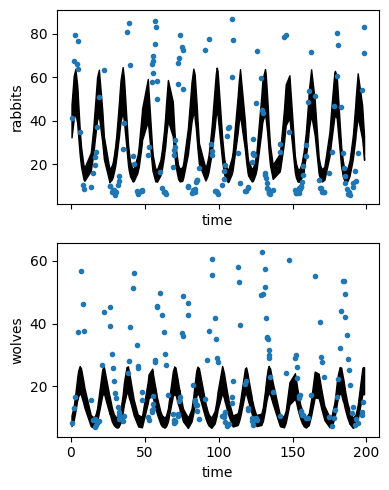

In [16]:
sim.posterior_predictive_checks()
#sim.posterior_predictive_checks(pred_hdi_style={"alpha": 0.2})